# EJ3 PANDAS - ALVARO FERNANDEZ


0. Conteo inicial de valores para paises. Queremos quedarnos con la columna que tiene más valores. Si alguna tiene valor nulo lo cogeremos de la otra. Las que tengan nulo en los dos las eliminamos.
Ten en cuenta que hay paises que tienen varios valores separados por comas. Quédate con el primero.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('artists.csv')

# Verificar las columnas de pais
print("Columnas relacionadas con país:")
print(df[['country_mb', 'country_lastfm']].head())

# Contar valores no nulos
country_non_null = df['country_mb'].notna().sum()
country_mb_non_null = df['country_lastfm'].notna().sum()
print(f"Valores no nulos en 'country_mb': {country_non_null}")
print(f"Valores no nulos en 'country_lastfm': {country_mb_non_null}")

# Elegir la columna con mas valores
if country_non_null >= country_mb_non_null:
    df['country_final'] = df['country_mb'].fillna(df['country_lastfm'])
else:
    df['country_final'] = df['country_lastfm'].fillna(df['country_mb'])

# Eliminar filas donde ambas son nulas
df = df[df['country_final'].notna()]

# Para países con varios, quedarse con el primero
df['country_final'] = df['country_final'].str.split(',').str[0].str.strip()

C:\Users\alvar\AppData\Local\Temp\ipykernel_52076\4102360963.py:3: DtypeWarning: Columns (2,4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('artists.csv')


Columnas relacionadas con país:
       country_mb           country_lastfm
0  United Kingdom           United Kingdom
1  United Kingdom           United Kingdom
2   United States            United States
3   United States  Barbados; United States
4   United States            United States
Valores no nulos en 'country_mb': 662368
Valores no nulos en 'country_lastfm': 211498
Columna 'country_final' creada.


1. Relleno de valores nulos en oyentes y reproducciones
Identificar los valores nulos y rellenar los oyentes con el promedio de oyentes por país basado en la columna country_mb y las reproducciones con el minimo

Razona por qué tendrían sentido cada una de las estrategias




In [10]:
# Rellenar oyentes con promedio por país
df['listeners_lastfm'] = df['listeners_lastfm'].fillna(df.groupby('country_final')['listeners_lastfm'].transform('mean'))

# Rellenar reproducciones con mínimo
min_plays = df['scrobbles_lastfm'].min()
df['scrobbles_lastfm'] = df['scrobbles_lastfm'].fillna(min_plays)

- Oyentes: El promedio por país tiene sentido porque artistas de países similares pueden tener oyentes parecidos.

- Reproducciones: El mínimo evita inflar los datos con valores altos, pero podría no ser el más representativo; sin embargo, según el enunciado, se usa el mínimo.

2. Establecer un rango de oyentes, por ejemplo, entre 500,000 y 2 millones, y filtrar los artistas que estén dentro de este rango.



In [11]:
# Filtrar oyentes entre 500000 y 2000000
df_filtered = df[(df['listeners_lastfm'] >= 500000) & (df['listeners_lastfm'] <= 2000000)]
print(f"Artistas en el rango: {len(df_filtered)}")

Artistas en el rango: 1654


3. Crea un histograma para analizar la distribución del número de oyentes. Los rangos deben ser de 100000 unidades

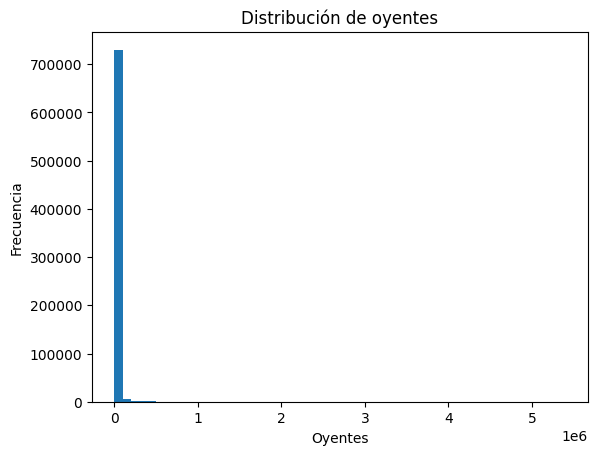

In [13]:
# Histograma de oyentes 
plt.hist(df['listeners_lastfm'], bins=range(0, int(df['listeners_lastfm'].max()) + 100000, 100000))
plt.xlabel('Oyentes')
plt.ylabel('Frecuencia')
plt.title('Distribución de oyentes')
plt.show()

4. Elige el límite a partir del cual podemos considerar que la frecuencia se mantiene y vuelve a filtrar para quedarte con esos artistas.  Muestra el gráfico de tarta que represente esta distribución.

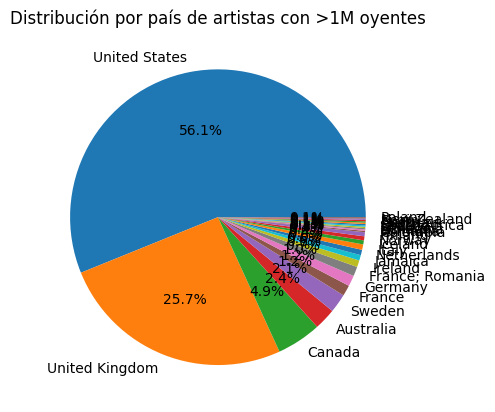

In [14]:
# Elegir limite, por ejemplo 1000000
df_top = df[df['listeners_lastfm'] > 1000000]
# print(df_top.head(3))

# Gráfico de tarta por pais
country_counts = df_top['country_final'].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%')
plt.title('Distribución por país de artistas con >1M oyentes')
plt.show()

5. Como puedes observar el gráfico anterior queda distorsionado por la presencia de paises que representan menos del 1%. 
Eliminalos y dibuja el gráfico de nuevo

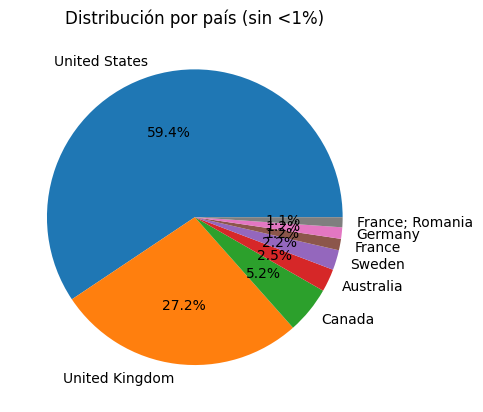

In [15]:
# Eliminar países con <1%
total = country_counts.sum()
rango = 0.01 * total
country_counts_filtered = country_counts[country_counts >= rango]
plt.pie(country_counts_filtered, labels=country_counts_filtered.index, autopct='%1.1f%%')
plt.title('Distribución por país (sin <1%)')
plt.show()

6. Continuando con el filtro anterior (entre 500000 y 2 millones) Haz un conteo de las etiquetas mas comunes en cada una de las plataformas y muestras las 10 primeras

In [ ]:
# Etiquetas más comunes en cada plataforma
tags_lastfm = df_filtered['tags_lastfm'].str.split(';').explode().value_counts().head(10)
print("---Top 10 tags LastFM---")
print(tags_lastfm)

tags_mb = df_filtered['tags_mb'].str.split(',').explode().value_counts().head(10)
print("\n---Top 10 tags MusicBrainz---")
print(tags_mb)

---Top 10 tags LastFM---
tags_lastfm
seen live         1257
rock              1029
alternative        984
pop                891
american           786
indie              726
male vocalists     668
USA                647
00s                614
electronic         552
Name: count, dtype: int64

---Top 10 tags MusicBrainz---
tags_mb
rock and indie                          22
hip hop                                 13
hip hop; hip hop rnb and dance hall     10
rock                                     8
folk                                     6
pop and chart                            6
hip hop rnb and dance hall               5
dance and electronica                    5
british; uk; english; rock and indie     4
indie; rock and indie                    4
Name: count, dtype: int64


7. Compara las etiquetas más frecuentes entre ambas plataformas en un gráfico de barras apiladas

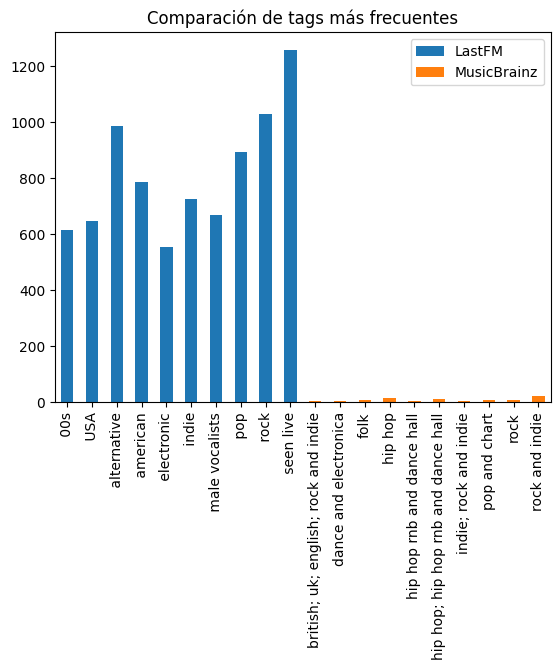

In [21]:
# Gráfico de barras apiladas comparando top tags
top_tags = pd.DataFrame({'LastFM': tags_lastfm, 'MusicBrainz': tags_mb}).fillna(0)
top_tags.plot(kind='bar', stacked=True)
plt.title('Comparación de tags más frecuentes')
plt.show()

8. Representa en dos gráficos de barras el top 10 de las etiquetas de ambas plataformas

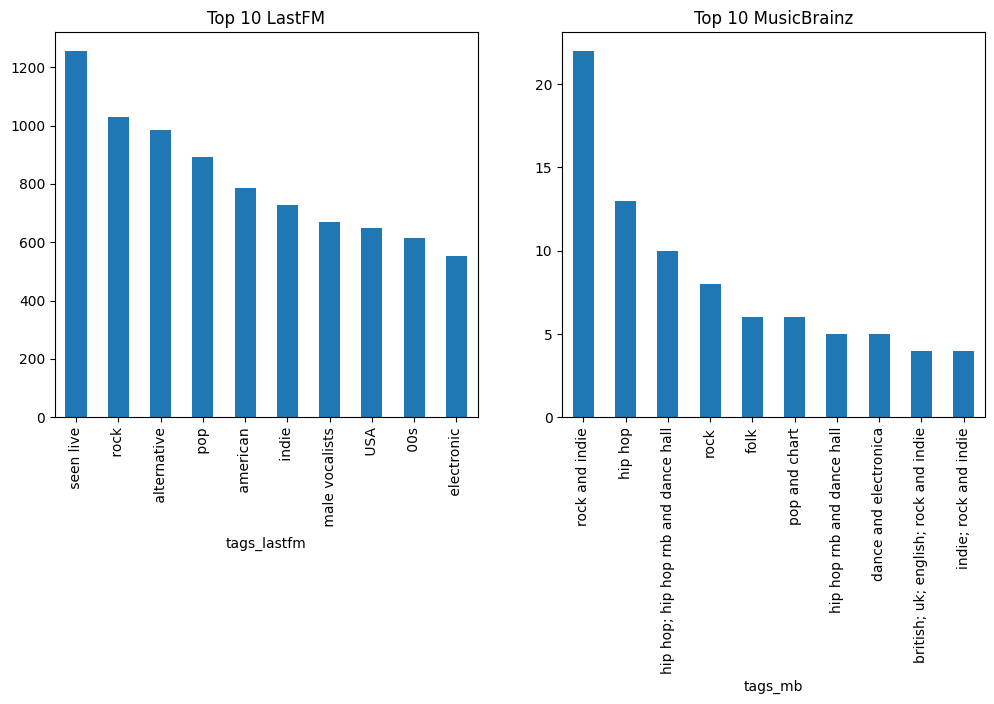

In [22]:
# Dos gráficos de barras para top 10 de cada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
tags_lastfm.head(10).plot(kind='bar', ax=ax1, title='Top 10 LastFM')
tags_mb.head(10).plot(kind='bar', ax=ax2, title='Top 10 MusicBrainz')
plt.show()

9. Representa en un gráfico de tarta las etiquetas más comunes en España. Junta las etiquetas de ambas plataformas

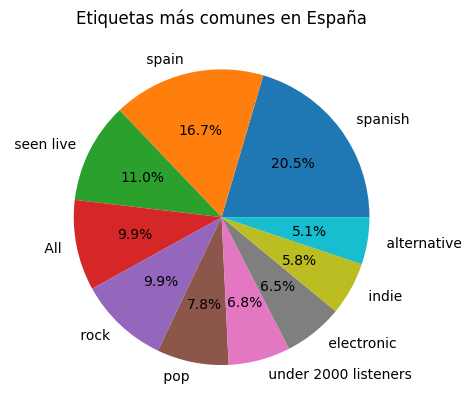

In [24]:
# Etiquetas en España, juntar ambas plataformas
df_spain = df[df['country_final'] == 'Spain']
tags_lastfm_spain = df_spain['tags_lastfm'].str.split(';').explode()
tags_mb_spain = df_spain['tags_mb'].str.split(',').explode()
tags_spain = pd.concat([tags_lastfm_spain, tags_mb_spain]).value_counts()
plt.pie(tags_spain.head(10), labels=tags_spain.head(10).index, autopct='%1.1f%%')
plt.title('Etiquetas más comunes en España')
plt.show()

10. Busca quienes son los artistas más vistos en directo en España, y representa sus oyentes y reproducciones en un gráfico de líneas creciente

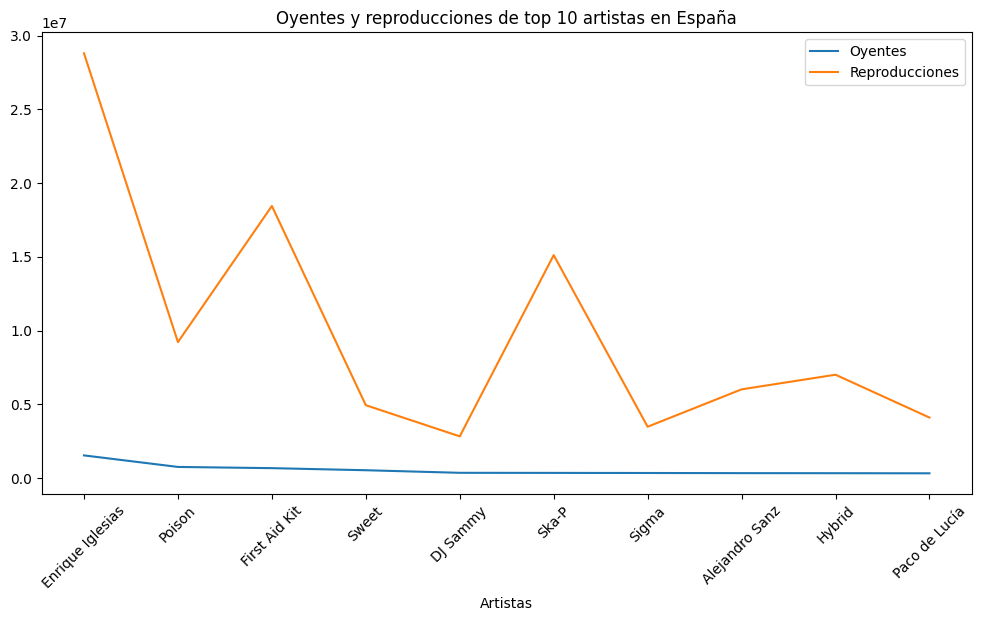

In [38]:
# Artistas más vistos en directo en España (usando listeners_lastfm como proxy)
df_spain = df[df['country_final'] == 'Spain']
df_spain_sorted = df_spain.sort_values('listeners_lastfm', ascending=False).head(10)

# Gráfico de líneas creciente: oyentes y reproducciones
plt.figure(figsize=(12,6))
plt.plot(df_spain_sorted['listeners_lastfm'].values, label='Oyentes')
plt.plot(df_spain_sorted['scrobbles_lastfm'].values, label='Reproducciones')
plt.xticks(range(len(df_spain_sorted)), df_spain_sorted['artist_mb'], rotation=45)
plt.xlabel('Artistas')
plt.legend()
plt.title('Oyentes y reproducciones de top 10 artistas en España')
plt.show()

11. Has visto que tienes un outlier. Busca qué grupo es y muéstralo

In [33]:
# Outlier
outlier = df_spain[df_spain['listeners_lastfm'] == df_spain['listeners_lastfm'].max()]
print("Outlier:")
print(outlier[['artist_mb', 'listeners_lastfm', 'scrobbles_lastfm']])

Outlier:
            artist_mb  listeners_lastfm  scrobbles_lastfm
330  Enrique Iglesias         1549855.0        28799602.0


12. Puede que tengas filas repetidas, por las etiquetas. Modifica el dataframe para que tenga valores únicos. 
Filtra para eliminar el outlier.
Vuelve a pintar el gráfico del punto 10.

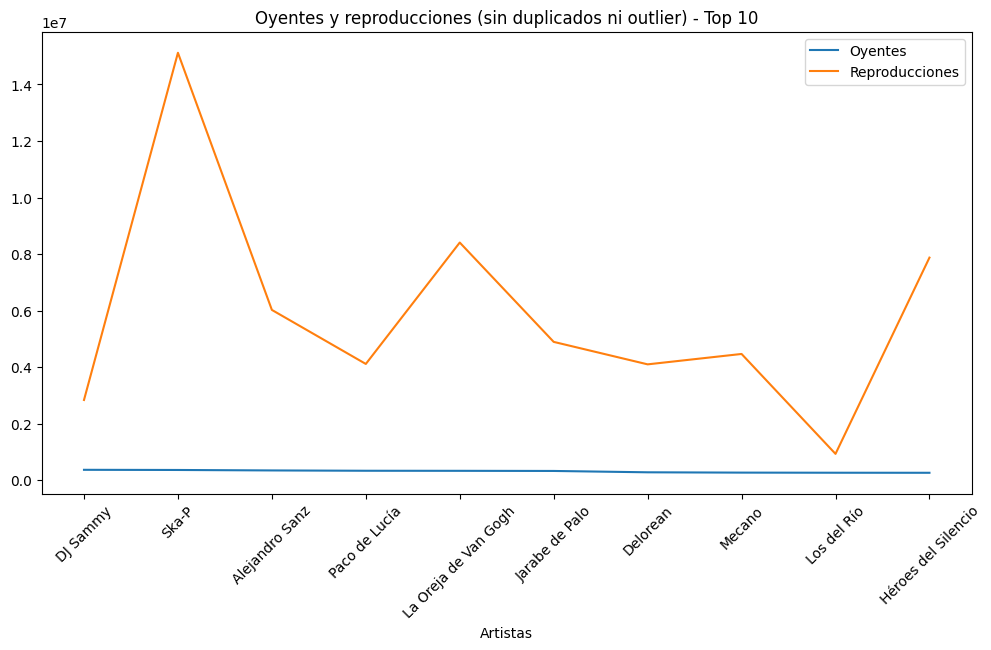

In [39]:
# Eliminar filas repetidas por etiquetas
df_unique = df.drop_duplicates(subset=['artist_mb'])

# Filtrar outlier
outlier = df_spain[df_spain['listeners_lastfm'] == df_spain['listeners_lastfm'].max()]
df_unique = df_unique[df_unique['listeners_lastfm'] != outlier['listeners_lastfm'].values[0]]

# Volver a graficar
df_spain_unique = df_unique[df_unique['country_final'] == 'Spain'].sort_values('listeners_lastfm', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.plot(df_spain_unique['listeners_lastfm'].values, label='Oyentes')
plt.plot(df_spain_unique['scrobbles_lastfm'].values, label='Reproducciones')
plt.xticks(range(len(df_spain_unique)), df_spain_unique['artist_mb'], rotation=45)
plt.xlabel('Artistas')
plt.legend()
plt.title('Oyentes y reproducciones (sin duplicados ni outlier) - Top 10')
plt.show()

13. Quédate con los 30 primeros que tengan más oyentes y vuelve a graficar. Hazlo mismo para las 30 primeros en cantidad de reproducciones

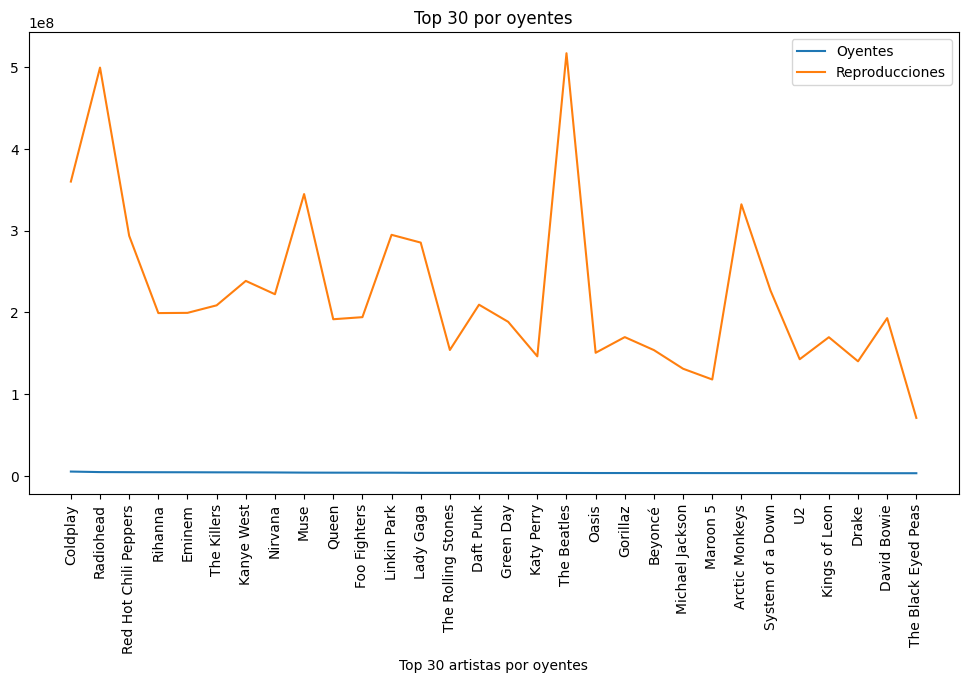

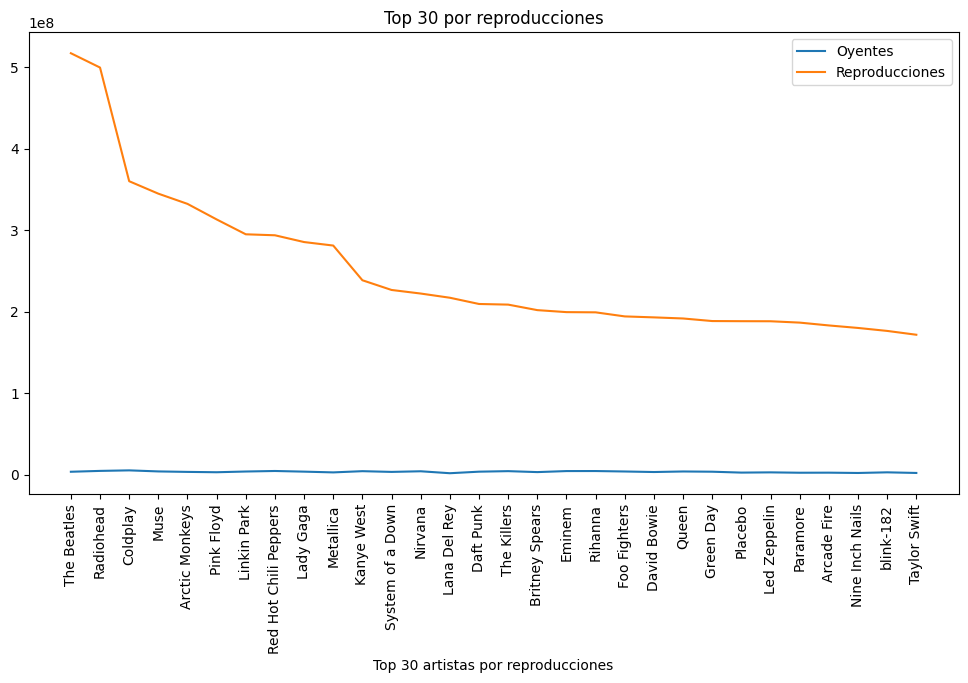

In [35]:
# Top 30 por oyentes
top_30_listeners = df.nlargest(30, 'listeners_lastfm')
plt.figure(figsize=(12,6))
plt.plot(top_30_listeners['listeners_lastfm'].values, label='Oyentes')
plt.plot(top_30_listeners['scrobbles_lastfm'].values, label='Reproducciones')
plt.xticks(range(len(top_30_listeners)), top_30_listeners['artist_mb'], rotation=90)
plt.xlabel('Top 30 artistas por oyentes')
plt.legend()
plt.title('Top 30 por oyentes')
plt.show()

# Top 30 por reproducciones
top_30_plays = df.nlargest(30, 'scrobbles_lastfm')
plt.figure(figsize=(12,6))
plt.plot(top_30_plays['listeners_lastfm'].values, label='Oyentes')
plt.plot(top_30_plays['scrobbles_lastfm'].values, label='Reproducciones')
plt.xticks(range(len(top_30_plays)), top_30_plays['artist_mb'], rotation=90)
plt.xlabel('Top 30 artistas por reproducciones')
plt.legend()
plt.title('Top 30 por reproducciones')
plt.show()